 # MCM 2026 Templates 模块验证



 本 Notebook 对 `templates` 中的所有模块和函数进行全面验证。



 模块结构：

 - `data`：数据加载、预处理、特征工程

 - `viz`：可视化（Plotly 交互式 + Matplotlib 论文级）

 - `ml`：机器学习（回归、分类、聚类）

 - `stats`：统计分析（相关分析、假设检验、评价模型）

 - `utils`：工具（Typst 导出、格式化、计时）

In [1]:
# 导入所有模块
import time
from datetime import date, timedelta

import matplotlib
import numpy as np
import polars as pl

from templates import data, ml, stats, utils, viz
from templates.viz import mpl

# matplotlib.use("Agg")

print("✅ 所有模块导入成功")


✅ 所有模块导入成功


 ## 1. 创建测试数据

In [2]:
# 设置随机种子
np.random.seed(42)

# 创建测试数据
n_samples = 200

# 生成时间序列测试数据
dates = [date(2020, 1, 1) + timedelta(days=i) for i in range(n_samples)]

# 生成特征和目标变量
x1 = np.random.randn(n_samples) * 10 + 50
x2 = np.random.randn(n_samples) * 5 + 30
x3 = np.random.randn(n_samples) * 8 + 40
noise = np.random.randn(n_samples) * 2
y = 2 * x1 + 1.5 * x2 - 0.5 * x3 + noise + 10

# 添加一些缺失值
x1_list = x1.tolist()
for idx in np.random.choice(n_samples, 10, replace=False):
    x1_list[idx] = None

# 添加异常值
x2_list = x2.tolist()
for idx in np.random.choice(n_samples, 5, replace=False):
    x2_list[idx] = 100.0  # 异常值

# 创建分组变量
groups = np.random.choice(["A", "B", "C"], n_samples)
binary_group = np.random.choice(["Control", "Treatment"], n_samples)

# 创建 DataFrame
df = pl.DataFrame(
    {
        "date": dates,
        "x1": x1_list,
        "x2": x2_list,
        "x3": x3.tolist(),
        "y": y.tolist(),
        "group": groups.tolist(),
        "binary_group": binary_group.tolist(),
        "category": np.random.choice(["Cat1", "Cat2", "Cat3"], n_samples).tolist(),
    }
)

print(f"测试数据维度：{df.shape}")
print(f"x1 缺失值数：{df['x1'].null_count()}")
print("\n数据预览:")
df.head()


测试数据维度：(200, 8)
x1 缺失值数：10

数据预览:


date,x1,x2,x3,y,group,binary_group,category
date,f64,f64,f64,f64,str,str,str
2020-01-01,54.967142,31.788937,27.244579,155.509376,"""A""","""Control""","""Cat1"""
2020-01-02,48.617357,32.803923,35.205,136.993767,"""A""","""Treatment""","""Cat2"""
2020-01-03,56.476885,35.415256,40.04195,157.794892,"""C""","""Control""","""Cat3"""
2020-01-04,65.230299,35.26901,40.375845,175.887466,"""A""","""Control""","""Cat1"""
2020-01-05,47.658466,23.111653,36.399476,122.611544,"""C""","""Treatment""","""Cat2"""


In [3]:
# 1.2 保存并加载数据
print("数据加载（load_csv / load_data）")
df.write_csv("outputs/test_data.csv")
df_loaded = data.load_csv("outputs/test_data.csv")
print(f"从 CSV 加载：{df_loaded.shape}")

# load_data 自动识别格式
df_auto = data.load_data("outputs/test_data.csv")
print(f"自动识别加载：{df_auto.shape}")


数据加载（load_csv / load_data）
从 CSV 加载：(200, 8)
自动识别加载：(200, 8)


 ## 2. 数据探索模块（data.explore）

In [4]:
# 2.1 数据描述统计
print("数据描述统计（describe_df）")
stats_df = data.describe_df(df)
stats_df


数据描述统计（describe_df）


column,dtype,count,null_count,null_pct,unique_count,top_value,top_freq,mean,std,min,max,p25,p50,p75
str,str,i64,i64,f64,i64,str,i64,f64,f64,f64,f64,f64,f64,f64
"""date""","""Date""",200,0,0.0,200,"""2020-03-07""",1,null,null,null,null,null,null,null
"""x1""","""Float64""",200,10,5.0,191,null,null,49.644145,9.363466,23.802549,77.201692,42.856486,50.130019,55.132674
"""x2""","""Float64""",200,0,0.0,196,null,null,32.183994,11.939742,13.793663,100.0,27.003037,30.567587,33.958313
"""x3""","""Float64""",200,0,0.0,200,null,null,39.31476,7.952336,20.226844,64.631046,33.657017,39.471362,44.564789
"""y""","""Float64""",200,0,0.0,200,null,null,135.189146,21.672111,65.848889,194.794691,119.904562,137.935995,150.747777
"""group""","""String""",200,0,0.0,3,"""A""",69,null,null,null,null,null,null,null
"""binary_group""","""String""",200,0,0.0,2,"""Control""",102,null,null,null,null,null,null,null
"""category""","""String""",200,0,0.0,3,"""Cat2""",79,null,null,null,null,null,null,null


In [5]:
# 2.2 缺失值报告
print("缺失值报告（missing_report）")
missing = data.missing_report(df)
missing


缺失值报告（missing_report）


column,dtype,missing_count,missing_pct,non_missing
str,str,i64,f64,i64
"""x1""","""Float64""",10,5.0,190
"""date""","""Date""",0,0.0,200
"""x2""","""Float64""",0,0.0,200
"""x3""","""Float64""",0,0.0,200
"""y""","""Float64""",0,0.0,200
"""group""","""String""",0,0.0,200
"""binary_group""","""String""",0,0.0,200
"""category""","""String""",0,0.0,200


In [6]:
# 2.3 异常值检测
print("异常值检测（detect_outliers） - IQR 方法")
outliers_iqr = data.detect_outliers(df, method="iqr")
outliers_iqr


异常值检测（detect_outliers） - IQR 方法


column,method,outlier_count,outlier_pct,lower_bound,upper_bound,actual_min,actual_max
str,str,i64,f64,f64,f64,f64,f64
"""x2""","""iqr""",7,3.5,16.5701,44.3912,13.793663,100.0
"""x1""","""iqr""",3,1.58,24.4422,73.547,23.802549,77.201692
"""x3""","""iqr""",1,0.5,17.2954,60.9264,20.226844,64.631046
"""y""","""iqr""",1,0.5,73.6397,197.0126,65.848889,194.794691


In [7]:
# 2.4 相关系数矩阵
print("相关系数矩阵（correlation_matrix）")
corr_df = data.correlation_matrix(df, columns=["x1", "x2", "x3", "y"])
corr_df


相关系数矩阵（correlation_matrix）


variable,x1,x2,x3,y
str,f64,f64,f64,f64
"""x1""",1.0,-0.02714,-0.133335,0.922988
"""x2""",-0.02714,1.0,-0.066304,0.111544
"""x3""",-0.133335,-0.066304,1.0,-0.293367
"""y""",0.922988,0.111544,-0.293367,1.0


 ## 3. 数据预处理模块（data.preprocess）

In [8]:
# 3.1 处理缺失值
print("处理缺失值（handle_missing） - 中位数填充")
df_no_missing = data.handle_missing(df, strategy="median")
print(f"处理前缺失值：{df['x1'].null_count()}")
print(f"处理后缺失值：{df_no_missing['x1'].null_count()}")


处理缺失值（handle_missing） - 中位数填充
处理前缺失值：10
处理后缺失值：0


In [9]:
# 3.2 处理异常值
print("处理异常值（handle_outliers） - IQR 裁剪")
df_no_outliers = data.handle_outliers(df_no_missing, method="iqr", action="clip")
print(f"x2 处理前范围：[{df['x2'].min():.2f}, {df['x2'].max():.2f}]")
print(
    f"x2 处理后范围：[{df_no_outliers['x2'].min():.2f}, {df_no_outliers['x2'].max():.2f}]"
)


处理异常值（handle_outliers） - IQR 裁剪
x2 处理前范围：[13.79, 100.00]
x2 处理后范围：[16.57, 44.39]


In [10]:
# 3.3 标准化
print("标准化（standardize） - Z-score")
df_standardized, std_params = data.standardize(
    df_no_outliers, columns=["x1", "x2", "x3"]
)
print(
    f"x1 标准化后：mean={df_standardized['x1'].mean():.4f}, std={df_standardized['x1'].std():.4f}"
)


标准化（standardize） - Z-score
x1 标准化后：mean=0.0000, std=1.0000


In [11]:
# 3.4 归一化
print("归一化（normalize） - MinMax")
df_normalized, norm_params = data.normalize(
    df_no_outliers, columns=["x1", "x2"], method="minmax"
)
print(
    f"x1 归一化后范围：[{df_normalized['x1'].min():.4f}, {df_normalized['x1'].max():.4f}]"
)


归一化（normalize） - MinMax
x1 归一化后范围：[0.0000, 1.0000]


In [12]:
# 3.5 一站式预处理流水线
print("预处理流水线（preprocess_pipeline）")
df_clean, params = data.preprocess_pipeline(
    df,
    drop_high_missing=0.5,
    handle_missing_strategy="median",
    handle_outliers_method="iqr",
    outlier_action="clip",
)
print(f"清洗后数据维度：{df_clean.shape}")
print(f"处理参数：{list(params.keys())}")


预处理流水线（preprocess_pipeline）
清洗后数据维度：(190, 8)
处理参数：['steps']


 ## 4. 特征工程模块（data.features）

In [13]:
# 4.1 时间特征
print("时间特征（create_time_features）")
df_time = data.create_time_features(
    df_clean, "date", features=["year", "month", "weekday", "is_weekend"]
)
print(f"新增列：{[c for c in df_time.columns if 'date_' in c]}")
df_time.select(
    [
        "date",
        "date_year",
        "date_month",
        "date_weekday",
        "date_is_weekend",
    ]
).head()


时间特征（create_time_features）
新增列：['date_year', 'date_month', 'date_weekday', 'date_is_weekend']


date,date_year,date_month,date_weekday,date_is_weekend
date,i32,i8,i8,bool
2020-01-01,2020,1,3,false
2020-01-02,2020,1,4,false
2020-01-03,2020,1,5,false
2020-01-04,2020,1,6,true
2020-01-05,2020,1,7,true


In [14]:
# 4.2 滞后特征
print("滞后特征（create_lag_features）")
df_lag = data.create_lag_features(
    df_clean, columns=["y"], lags=[1, 3, 7], sort_by="date"
)
print(f"新增列：{[c for c in df_lag.columns if 'lag' in c]}")
df_lag.select(["date", "y", "y_lag_1", "y_lag_3", "y_lag_7"]).head(10)


滞后特征（create_lag_features）
新增列：['y_lag_1', 'y_lag_3', 'y_lag_7']


date,y,y_lag_1,y_lag_3,y_lag_7
date,f64,f64,f64,f64
2020-01-01,155.509376,null,null,null
2020-01-02,136.993767,155.509376,null,null
2020-01-03,157.794892,136.993767,null,null
2020-01-04,175.887466,157.794892,155.509376,null
2020-01-05,122.611544,175.887466,136.993767,null
2020-01-06,124.545765,122.611544,157.794892,null
2020-01-07,173.169924,124.545765,175.887466,null
2020-01-09,125.434747,173.169924,122.611544,155.509376
2020-01-10,175.68102,125.434747,124.545765,136.993767


In [15]:
# 4.3 滚动特征
print("滚动特征（create_rolling_features）")
df_rolling = data.create_rolling_features(
    df_clean, columns=["y"], windows=[7], functions=["mean", "std"], sort_by="date"
)
rolling_cols = [c for c in df_rolling.columns if "rolling" in c]
print(f"新增列：{rolling_cols}")
df_rolling.select(["date", "y"] + rolling_cols).tail(10)


滚动特征（create_rolling_features）
新增列：['y_rolling_mean_7', 'y_rolling_std_7']


date,y,y_rolling_mean_7,y_rolling_std_7
date,f64,f64,f64
2020-07-08,100.478692,133.475095,19.383857
2020-07-09,119.904562,131.626506,20.059264
2020-07-10,158.143375,136.328507,22.066957
2020-07-11,128.007364,132.961468,21.130865
2020-07-12,119.93302,128.590012,20.026182
2020-07-13,140.997147,127.027827,18.249533
2020-07-14,143.333902,130.114009,19.015033
2020-07-15,105.474732,130.827729,17.770317
2020-07-16,153.506601,135.62802,18.83446


In [16]:
# 4.4 分类编码
print("分类编码（encode_categorical） - One-Hot")
df_encoded, enc_mapping = data.encode_categorical(
    df_clean, columns=["category"], method="onehot"
)
print(f"编码后新增列：{[c for c in df_encoded.columns if 'category_' in c]}")
df_encoded.select([c for c in df_encoded.columns if "category" in c]).head()


分类编码（encode_categorical） - One-Hot
编码后新增列：['category_Cat3', 'category_Cat2', 'category_Cat1']


category_Cat3,category_Cat2,category_Cat1
i8,i8,i8
0,0,1
0,1,0
1,0,0
0,0,1
0,1,0


In [17]:
# 4.5 交互特征
print("交互特征（create_interaction_features）")
df_interact = data.create_interaction_features(
    df_clean, column_pairs=[("x1", "x2")], operations=["multiply", "divide"]
)
interact_cols = [c for c in df_interact.columns if "x1" in c and "x2" in c]
print(f"新增列：{interact_cols}")
df_interact.select(["x1", "x2"] + interact_cols).head()


交互特征（create_interaction_features）
新增列：['x1_x_x2', 'x1_div_x2']


x1,x2,x1_x_x2,x1_div_x2
f64,f64,f64,f64
54.967142,31.788937,1747.346988,1.729128
48.617357,32.803923,1594.840017,1.482059
56.476885,35.415256,2000.143366,1.594705
65.230299,35.26901,2300.608069,1.849507
47.658466,23.111653,1101.465942,2.062097


 ## 5. 可视化模块（viz）- Plotly 交互式图表

In [18]:
# 5.1 折线图
print("折线图（line_plot）")
fig = viz.line_plot(
    df_clean.sort("date").head(50),
    x="date",
    y="y",
    title="时间序列趋势",
    show_markers=True,
)
fig.show()


折线图（line_plot）


In [19]:
# 5.2 散点图
print("散点图（scatter_plot）")
fig = viz.scatter_plot(
    df_clean,
    x="x1",
    y="y",
    color="group",
    title="X1 vs Y 散点图",
    show_trendline=True,
)
fig.show()


散点图（scatter_plot）


In [20]:
# 5.3 柱状图
print("柱状图（bar_plot）")
# 创建分组统计数据
bar_data = df_clean.group_by("group").agg(pl.col("y").mean().alias("mean_y"))
fig = viz.bar_plot(
    bar_data,
    x="group",
    y="mean_y",
    title="各组平均 Y 值",
    show_values=True,
)
fig.show()


柱状图（bar_plot）


In [21]:
# 5.4 热力图
print("热力图（heatmap）")
corr_matrix = data.correlation_matrix(df_clean, columns=["x1", "x2", "x3", "y"])
fig = viz.heatmap(
    corr_matrix,
    title="相关系数矩阵",
    show_values=True,
)
fig.show()


热力图（heatmap）


In [22]:
# 5.5 箱线图
print("箱线图（box_plot）")
fig = viz.box_plot(
    df_clean,
    y="y",
    x="group",
    title="各组 Y 值分布",
    show_points=True,
)
fig.show()


箱线图（box_plot）


In [23]:
# 5.6 直方图
print("直方图（histogram）")
fig = viz.histogram(
    df_clean,
    x="y",
    bins=30,
    title="Y 值分布",
    show_kde=True,
)
fig.show()


直方图（histogram）


In [24]:
# 5.7 雷达图
print("雷达图（radar_plot）")
radar_data = pl.DataFrame(
    {
        "name": ["Model A", "Model B"],
        "Accuracy": [0.85, 0.78],
        "Precision": [0.82, 0.80],
        "Recall": [0.88, 0.75],
        "F1": [0.85, 0.77],
        "Speed": [0.90, 0.95],
    }
)
fig = viz.radar_plot(
    radar_data,
    categories=["Accuracy", "Precision", "Recall", "F1", "Speed"],
    name_col="name",
    title="模型性能对比",
)
fig.show()


雷达图（radar_plot）


In [25]:
# 5.8 子图网格
print("子图网格（subplot_grid）")
figs = [
    viz.scatter_plot(df_clean, x="x1", y="y", title="X1 vs Y"),
    viz.scatter_plot(df_clean, x="x2", y="y", title="X2 vs Y"),
    viz.histogram(df_clean, x="y", title="Y 分布"),
    viz.box_plot(df_clean, y="y", x="group", title="Y by Group"),
]
fig = viz.subplot_grid(figs, rows=2, cols=2, main_title="多图组合")
fig.show()


子图网格（subplot_grid）


In [26]:
# 5.9 主题与配色
print("主题与配色（apply_theme / get_color_palette）")
colors = viz.get_color_palette("nature", n_colors=5)
print(f"Nature 配色：{colors}")

fig = viz.scatter_plot(df_clean, x="x1", y="y", title="自定义主题")
fig = viz.apply_theme(fig, theme="science")
fig.show()


主题与配色（apply_theme / get_color_palette）
Nature 配色：['#E64B35', '#4DBBD5', '#00A087', '#3C5488', '#F39B7F']


 ## 6. 可视化模块（viz.mpl）- Matplotlib 论文级图表

In [27]:
# 6.1 配置全局样式
print("配置 Matplotlib 样式（setup_style）")
mpl.setup_style(style="nature", font_size=11)
print("✅ Nature 风格已配置")


配置 Matplotlib 样式（setup_style）
✅ Nature 风格已配置


Matplotlib 散点图（mpl.scatter_plot）


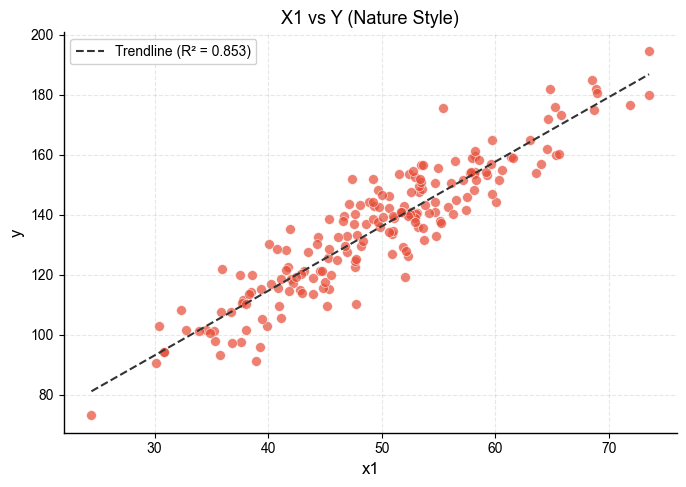

In [28]:
# 6.2 Matplotlib 散点图
print("Matplotlib 散点图（mpl.scatter_plot）")
fig = mpl.scatter_plot(
    df_clean,
    x="x1",
    y="y",
    title="X1 vs Y (Nature Style)",
    show_trendline=True,
    style="nature",
)


Matplotlib 热力图（mpl.heatmap）


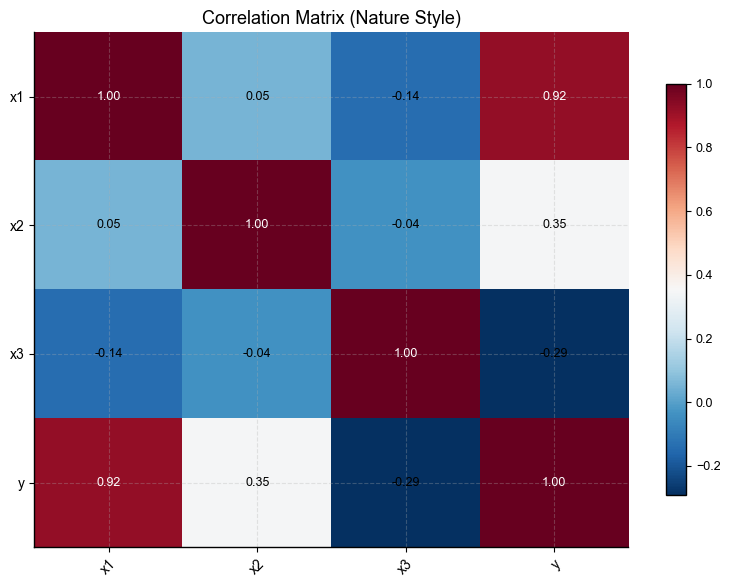

In [29]:
# 6.3 Matplotlib 热力图
print("Matplotlib 热力图（mpl.heatmap）")
fig = mpl.heatmap(
    corr_matrix,
    title="Correlation Matrix (Nature Style)",
    style="nature",
)


Matplotlib 柱状图（mpl.bar_plot）


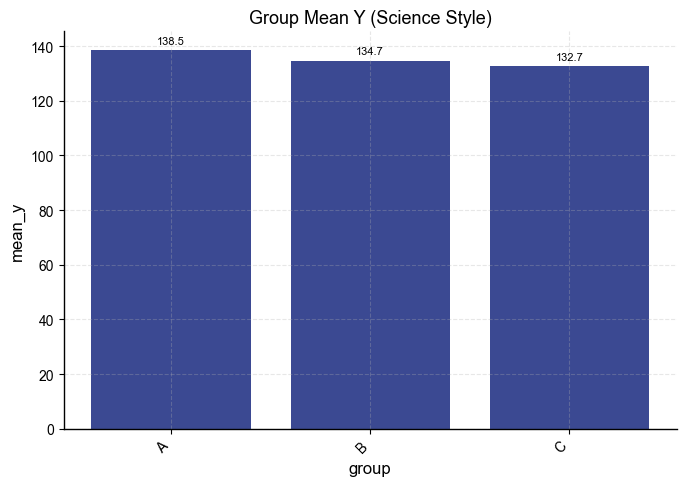

In [30]:
# 6.4 Matplotlib 柱状图
print("Matplotlib 柱状图（mpl.bar_plot）")
fig = mpl.bar_plot(
    bar_data,
    x="group",
    y="mean_y",
    title="Group Mean Y (Science Style)",
    style="science",
)


Matplotlib 直方图（mpl.histogram）


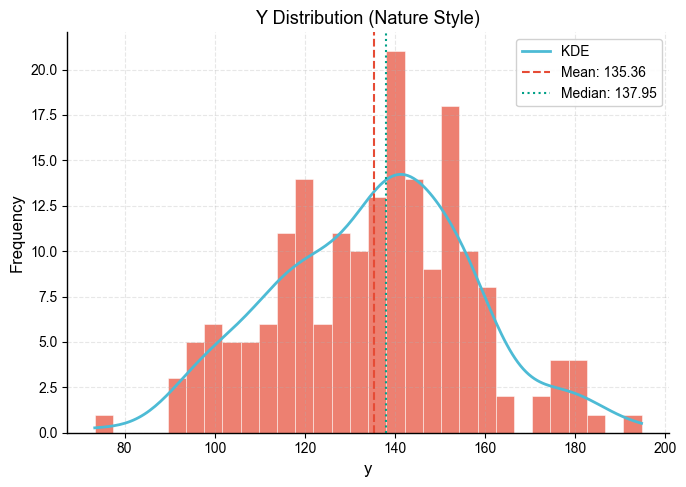

In [31]:
# 6.5 Matplotlib 直方图
print("Matplotlib 直方图（mpl.histogram）")
fig = mpl.histogram(
    df_clean,
    x="y",
    title="Y Distribution (Nature Style)",
    show_kde=True,
    style="nature",
)


Matplotlib 箱线图（mpl.box_plot）


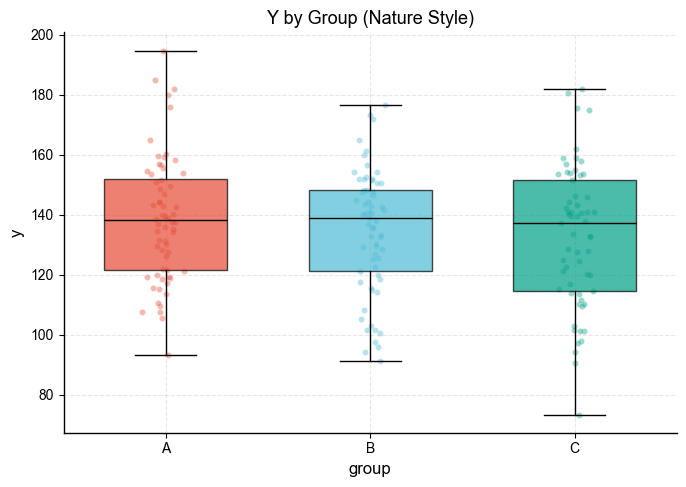

In [32]:
# 6.6 Matplotlib 箱线图
print("Matplotlib 箱线图（mpl.box_plot）")
fig = mpl.box_plot(
    df_clean,
    y="y",
    x="group",
    title="Y by Group (Nature Style)",
    style="nature",
)


In [33]:
# 关闭所有图表
mpl.close_all()
print("✅ 已关闭所有 Matplotlib 图表")


✅ 已关闭所有 Matplotlib 图表


 ## 7. 机器学习模块（ml）- 回归

In [34]:
# 准备 ML 数据
features = ["x1", "x2", "x3"]
target = "y"

print("7.1 随机森林回归 (train_random_forest)")

rf_model = ml.train_random_forest(
    df_clean.drop_nulls(),
    features=features,
    target=target,
    n_estimators=100,
    test_size=0.2,
)
print(f"R² = {rf_model.metrics['r2']:.4f}")
print(f"RMSE = {rf_model.metrics['rmse']:.4f}")
print(f"MAE = {rf_model.metrics['mae']:.4f}")
print("\n特征重要性:")
rf_model.get_feature_importance()


7.1 随机森林回归 (train_random_forest)
R² = 0.9551
RMSE = 4.0863
MAE = 3.3000

特征重要性:


feature,importance
str,f64
"""x1""",0.888559
"""x2""",0.076738
"""x3""",0.034703


In [35]:
# 7.2 Ridge 回归
print("Ridge 回归 (train_ridge)")

ridge_model = ml.train_ridge(
    df_clean.drop_nulls(),
    features=features,
    target=target,
    alpha=1.0,
)
print(f"R² = {ridge_model.metrics['r2']:.4f}")
print(f"RMSE = {ridge_model.metrics['rmse']:.4f}")


Ridge 回归 (train_ridge)
R² = 0.9703
RMSE = 3.3226


In [36]:
# 7.3 XGBoost 回归
print("XGBoost 回归 (train_xgboost)")

xgb_model = ml.train_xgboost(
    df_clean.drop_nulls(),
    features=features,
    target=target,
    n_estimators=100,
)
print(f"R² = {xgb_model.metrics['r2']:.4f}")
print(f"RMSE = {xgb_model.metrics['rmse']:.4f}")


XGBoost 回归 (train_xgboost)
R² = 0.9448
RMSE = 4.5321


In [37]:
# 7.4 集成模型
print("集成模型 (train_ensemble)")

ensemble_model = ml.train_ensemble(
    df_clean.drop_nulls(),
    features=features,
    target=target,
    models=["rf", "ridge"],
)
print(f"R² = {ensemble_model.metrics['r2']:.4f}")
print(f"RMSE = {ensemble_model.metrics['rmse']:.4f}")


集成模型 (train_ensemble)
R² = 0.9695
RMSE = 3.3703


In [38]:
# 7.5 模型预测
print("模型预测")

predictions = rf_model.predict(df_clean.drop_nulls().head(10))
actuals = df_clean.drop_nulls().head(10)["y"].to_numpy()

pred_df = pl.DataFrame(
    {
        "actual": actuals,
        "predicted": predictions,
        "error": actuals - predictions,
    }
)
pred_df


模型预测


actual,predicted,error
f64,f64,f64
155.509376,152.409322,3.100054
136.993767,138.63662,-1.642853
157.794892,155.734257,2.060635
175.887466,174.578218,1.309248
122.611544,124.33142,-1.719876
124.545765,126.387051,-1.841286
173.169924,172.875889,0.294035
125.434747,125.566162,-0.131415
175.68102,159.386326,16.294694


 ## 8. 机器学习模块（ml）- 分类

In [39]:
# 8.1 逻辑回归分类
print("逻辑回归分类（train_logistic）")

# 创建二分类目标
df_cls = df_clean.drop_nulls().with_columns(
    (pl.col("y") > pl.col("y").median()).cast(pl.Int32).alias("label")
)

logistic_model = ml.train_logistic(
    df_cls,
    features=features,
    target="label",
)
print(f"Accuracy = {logistic_model.metrics['accuracy']:.4f}")
print(f"F1 = {logistic_model.metrics['f1']:.4f}")


逻辑回归分类（train_logistic）
Accuracy = 0.7895
F1 = 0.8000


In [40]:
# 8.2 随机森林分类
print("随机森林分类（train_classifier）")

rf_classifier = ml.train_classifier(
    df_cls,
    features=features,
    target="label",
    model_type="rf",
)
print(f"Accuracy = {rf_classifier.metrics['accuracy']:.4f}")
print(f"F1 = {rf_classifier.metrics['f1']:.4f}")


随机森林分类（train_classifier）
Accuracy = 0.7895
F1 = 0.8000


 ## 9. 机器学习模块（ml）- 聚类

In [41]:
# 9.1 K-Means 聚类
print("K-Means 聚类（kmeans_cluster）")

df_clustered, kmeans_info = ml.kmeans_cluster(
    df_clean.drop_nulls(),
    features=features,
    n_clusters=3,
)
print(f"聚类数：{kmeans_info['n_clusters']}")
print(f"轮廓系数：{kmeans_info['silhouette_score']:.4f}")
print(f"各簇大小：{kmeans_info['cluster_sizes']}")


K-Means 聚类（kmeans_cluster）
聚类数：3
轮廓系数：0.2390
各簇大小：{np.int32(0): np.int64(64), np.int32(1): np.int64(70), np.int32(2): np.int64(56)}


In [42]:
# 9.2 自动寻找最优 K
print("K-Means 自动寻优（find_optimal_k=True）")

df_opt, opt_info = ml.kmeans_cluster(
    df_clean.drop_nulls(),
    features=features,
    find_optimal_k=True,
    k_range=(2, 6),
)
print(f"最优 K：{opt_info['n_clusters']}")
print(f"轮廓系数：{opt_info['silhouette_score']:.4f}")


K-Means 自动寻优（find_optimal_k=True）
最优 K：4
轮廓系数：0.2449


In [43]:
# 9.3 层次聚类
print("层次聚类（hierarchical_cluster）")

df_hier, hier_info = ml.hierarchical_cluster(
    df_clean.drop_nulls(),
    features=features,
    n_clusters=3,
    linkage="ward",
)
print(f"轮廓系数：{hier_info['silhouette_score']:.4f}")
print(f"各簇大小：{hier_info['cluster_sizes']}")


层次聚类（hierarchical_cluster）
轮廓系数：0.2255
各簇大小：{np.int64(0): np.int64(73), np.int64(1): np.int64(64), np.int64(2): np.int64(53)}


In [44]:
# 9.4 DBSCAN 聚类
print("DBSCAN 聚类（dbscan_cluster）")

df_dbscan, dbscan_info = ml.dbscan_cluster(
    df_clean.drop_nulls(),
    features=features,
    eps=0.8,
    min_samples=5,
)
print(f"聚类数：{dbscan_info['n_clusters']}")
print(f"噪声点数：{dbscan_info['n_noise_points']}")


DBSCAN 聚类（dbscan_cluster）
聚类数：1
噪声点数：34


 ## 10. 机器学习模块（ml）- 模型评估

In [45]:
# 10.1 交叉验证
print("交叉验证（cross_validate）")

cv_results = ml.cross_validate(
    rf_model.model,
    df_clean.drop_nulls(),
    features=features,
    target=target,
    cv=5,
)
print(f"CV R²：{cv_results['mean_score']:.4f} ± {cv_results['std_score']:.4f}")
print(f"各折得分：{[f'{s:.4f}' for s in cv_results['scores']]}")


交叉验证（cross_validate）
CV R²：0.9228 ± 0.0178
各折得分：['0.9501', '0.9026', '0.9368', '0.9143', '0.9102']


In [46]:
# 10.2 特征重要性
print("特征重要性（feature_importance）")

importance_df = ml.feature_importance(rf_model.model, features)
importance_df


特征重要性（feature_importance）


feature,importance,importance_pct
str,f64,f64
"""x1""",0.888559,88.855929
"""x2""",0.076738,7.673819
"""x3""",0.034703,3.470252


In [47]:
# 10.3 回归评估指标
print("回归评估指标（regression_metrics）")

y_true = df_clean.drop_nulls()["y"].to_numpy()
y_pred = rf_model.predict(df_clean.drop_nulls())
reg_metrics = ml.regression_metrics(y_true, y_pred)
print(f"R² = {reg_metrics['r2']:.4f}")
print(f"RMSE = {reg_metrics['rmse']:.4f}")
print(f"MAE = {reg_metrics['mae']:.4f}")
print(f"MAPE = {reg_metrics['mape']:.2f}%")


回归评估指标（regression_metrics）
R² = 0.9833
RMSE = 2.7893
MAE = 1.9018
MAPE = 1.45%


In [48]:
# 10.4 分类评估指标
print("分类评估指标（classification_metrics）")

y_true_cls = df_cls["label"].to_numpy()
y_pred_cls = logistic_model.predict(df_cls)
cls_metrics = ml.classification_metrics(y_true_cls, y_pred_cls)
print(f"Accuracy = {cls_metrics['accuracy']:.4f}")
print(f"Precision = {cls_metrics['precision']:.4f}")
print(f"Recall = {cls_metrics['recall']:.4f}")
print(f"F1 = {cls_metrics['f1']:.4f}")


分类评估指标（classification_metrics）
Accuracy = 0.9158
Precision = 0.8911
Recall = 0.9474
F1 = 0.9184


 ## 11. 统计分析模块（stats）- 相关分析

In [49]:
# 11.1 相关性检验
print("相关性检验（correlation_test）")

corr_result = stats.correlation_test(df_clean, "x1", "y", method="pearson")
print(f"方法：{corr_result['method']}")
print(f"相关系数：{corr_result['correlation']:.4f}")
print(f"P 值：{corr_result['p_value']:.4f}")
print(f"解释：{corr_result['interpretation']}")
print(f"显著：{'是' if corr_result['significant'] else '否'}")


相关性检验（correlation_test）
方法：pearson
相关系数：0.9237
P 值：0.0000
解释：very strong positive correlation
显著：是


In [50]:
# 11.2 Spearman 相关
print("Spearman 相关性检验（spearman_correlation_test）")

spearman_result = stats.correlation_test(df_clean, "x1", "y", method="spearman")
print(f"Spearman r = {spearman_result['correlation']:.4f}")
print(f"P 值：{spearman_result['p_value']:.4f}")


Spearman 相关性检验（spearman_correlation_test）
Spearman r = 0.9088
P 值：0.0000


In [51]:
# 11.3 偏相关分析
print("偏相关分析（partial_correlation）")

partial_result = stats.partial_correlation(df_clean, "x1", "y", control=["x2", "x3"])
print(f"控制变量：{partial_result['control_variables']}")
print(f"偏相关系数：{partial_result['partial_correlation']:.4f}")
print(f"P 值：{partial_result['p_value']:.4f}")


偏相关分析（partial_correlation）
控制变量：['x2', 'x3']
偏相关系数：0.9783
P 值：0.0000


In [52]:
# 11.4 相关性摘要
print("相关性摘要（correlation_summary）")

corr_summary = stats.correlation_summary(df_clean, columns=["x1", "x2", "x3", "y"])
corr_summary


相关性摘要（correlation_summary）


var1,var2,correlation,p_value,significant,strength
str,str,f64,f64,f64,str
"""x1""","""y""",0.92374,2.7806e-80,1.0,"""very strong"""


 ## 12. 统计分析模块（stats）- 假设检验

In [53]:
# 12.1 独立样本 t 检验
print("独立样本 t 检验（t_test）")

t_result = stats.t_test(df_clean, "y", group_by="binary_group")
print(f"t = {t_result['statistic']:.4f}")
print(f"p = {t_result['p_value']:.4f}")
print(f"Cohen's d = {t_result['cohens_d']:.4f}（{t_result['effect_size']}）")
print(f"显著：{'是' if t_result['significant'] else '否'}")
# 12.2 配对 t 检验
print("配对 t 检验（paired_t_test）")

# 添加配对数据
df_paired = df_clean.with_columns(
    (pl.col("y") + np.random.randn(len(df_clean)) * 5).alias("y_after")
)

paired_result = stats.paired_t_test(df_paired, "y", "y_after")
print(f"t = {paired_result['statistic']:.4f}")
print(f"p = {paired_result['p_value']:.4f}")
print(f"平均差异：{paired_result['mean_diff']:.4f}")


独立样本 t 检验（t_test）
t = 0.3209
p = 0.7486
Cohen's d = 0.0468（small）
显著：否
配对 t 检验（paired_t_test）
t = 0.3225
p = 0.7474
平均差异：0.1098


In [54]:
# 12.3 单因素方差分析（ANOVA）
print("单因素方差分析（anova）")

anova_result = stats.anova(df_clean, "y", group_by="group")
print(f"F = {anova_result['f_statistic']:.4f}")
print(f"p = {anova_result['p_value']:.4f}")
print(f"各组均值：{anova_result['group_means']}")


单因素方差分析（anova）
F = 1.1597
p = 0.3158
各组均值：{'C': 132.7346941785169, 'B': 134.72310286805657, 'A': 138.51831268621555}


In [55]:
# 12.4 卡方检验
print("卡方检验（chi_square_test）")

chi2_result = stats.chi_square_test(df_clean, "group", "binary_group")
print(f"χ² = {chi2_result['chi2_statistic']:.4f}")
print(f"p = {chi2_result['p_value']:.4f}")
print(f"自由度 = {chi2_result['degrees_of_freedom']}")
print(f"Cramér's V = {chi2_result['cramers_v']:.4f}")


卡方检验（chi_square_test）
χ² = 0.9607
p = 0.6186
自由度 = 2
Cramér's V = 0.0711


In [56]:
# 12.5 正态性检验
print("正态性检验（normality_test）")

normal_result = stats.normality_test(df_clean, "y")
print(f"统计量：{normal_result['statistic']:.4f}")
print(f"p = {normal_result['p_value']:.4f}")
print(f"是否正态：{'是' if normal_result['is_normal'] else '否'}")


正态性检验（normality_test）
统计量：0.9920
p = 0.3795
是否正态：是


 ## 13. 统计分析模块（stats）- 评价模型

In [57]:
# 13.1 AHP 层次分析法
print("AHP 层次分析法（ahp_weight）")

# 判断矩阵
ahp_matrix = [[1, 3, 5], [1 / 3, 1, 3], [1 / 5, 1 / 3, 1]]

ahp_result = stats.ahp_weight(ahp_matrix, criteria_names=["指标A", "指标B", "指标C"])
print(f"权重：{ahp_result['weights']}")
print(f"CR = {ahp_result['CR']:.4f}")
print(f"一致性：{'通过' if ahp_result['is_consistent'] else '不通过'}")


AHP 层次分析法（ahp_weight）
权重：{'指标A': np.float64(0.6369855717447568), '指标B': np.float64(0.2582849943744952), '指标C': np.float64(0.10472943388074796)}
CR = 0.0332
一致性：通过


In [58]:
# 13.2 熵权法
print("熵权法（entropy_weight）")

entropy_result = stats.entropy_weight(df_clean, columns=["x1", "x2", "x3"])
print(f"权重：{entropy_result['weights']}")
print(f"熵值：{entropy_result['entropy']}")


熵权法（entropy_weight）
权重：{'x1': np.float64(0.3077462623260331), 'x2': np.float64(0.2897540372278761), 'x3': np.float64(0.4024997004460908)}
熵值：{'x1': np.float64(0.9860689077371334), 'x2': np.float64(0.9868833817975564), 'x3': np.float64(0.9817795984902972)}


In [59]:
# 13.3 组合权重
print("组合权重（combine_weights）")

combined = stats.combine_weights(
    ahp_result["weights"],
    entropy_result["weights"],
    alpha=0.5,
)
print(f"组合权重：{combined}")


组合权重（combine_weights）
组合权重：{'x3': np.float64(0.20124985022304542), '指标C': np.float64(0.052364716940373986), 'x2': np.float64(0.1448770186139381), '指标A': np.float64(0.31849278587237845), 'x1': np.float64(0.15387313116301657), '指标B': np.float64(0.12914249718724763)}


In [60]:
# 13.4 TOPSIS 综合评价
print("TOPSIS 综合评价（topsis）")

# 创建评价数据
eval_df = df_clean.drop_nulls().head(20).with_row_index("id")

topsis_result = stats.topsis(
    eval_df,
    columns=["x1", "x2", "x3"],
    weights=[0.4, 0.3, 0.3],
    beneficial=["x1", "x3"],
    cost=["x2"],
    id_column="id",
)

print("TOPSIS 评价结果（Top 10）：")
topsis_result.sort("topsis_rank").head(10).select(["id", "topsis_score", "topsis_rank"])


TOPSIS 综合评价（topsis）
TOPSIS 评价结果（Top 10）：


id,topsis_score,topsis_rank
u32,f64,i64
19,0.671658,1
3,0.654343,2
16,0.610657,3
5,0.604078,4
6,0.602254,5
2,0.573052,6
15,0.55054,7
4,0.547493,8
17,0.532052,9


 ## 14. 统计分析模块（stats）- 敏感性分析

In [61]:
# 14.1 单参数敏感性分析
print("单参数敏感性分析（sensitivity_analysis）")


# 定义模型函数
def model_func(params):
    return params["a"] * 2 + params["b"] * 3 + params["c"] ** 2


base_params = {"a": 1.0, "b": 2.0, "c": 3.0}

sensitivity_df = stats.sensitivity_analysis(
    model_func,
    base_params,
    param_to_analyze="a",
    variation_range=(-0.3, 0.3),
    n_steps=10,
)
sensitivity_df


单参数敏感性分析（sensitivity_analysis）


param_name,param_value,param_change_pct,output,output_change_pct,sensitivity
str,f64,f64,f64,f64,f64
"""a""",0.7,-30.0,16.4,-3.529412,0.117647
"""a""",0.766667,-23.333333,16.533333,-2.745098,0.117647
"""a""",0.833333,-16.666667,16.666667,-1.960784,0.117647
"""a""",0.9,-10.0,16.8,-1.176471,0.117647
"""a""",0.966667,-3.333333,16.933333,-0.392157,0.117647
"""a""",1.033333,3.333333,17.066667,0.392157,0.117647
"""a""",1.1,10.0,17.2,1.176471,0.117647
"""a""",1.166667,16.666667,17.333333,1.960784,0.117647
"""a""",1.233333,23.333333,17.466667,2.745098,0.117647


In [62]:
# 14.2 多参数网格搜索
print("多参数网格搜索（parameter_sweep）")

sweep_df = stats.parameter_sweep(
    model_func,
    param_ranges={
        "a": (0.5, 1.5, 5),
        "b": (1.5, 2.5, 5),
        "c": (2.5, 3.5, 5),
    },
)
print(f"参数组合数：{len(sweep_df)}")
sweep_df.head(10)


多参数网格搜索（parameter_sweep）
参数组合数：125


a,b,c,output
f64,f64,f64,f64
0.5,1.5,2.5,11.75
0.5,1.5,2.75,13.0625
0.5,1.5,3.0,14.5
0.5,1.5,3.25,16.0625
0.5,1.5,3.5,17.75
0.5,1.75,2.5,12.5
0.5,1.75,2.75,13.8125
0.5,1.75,3.0,15.25
0.5,1.75,3.25,16.8125


In [63]:
# 14.3 龙卷风图数据
print("龙卷风图数据（tornado_diagram_data）")

tornado_df = stats.tornado_diagram_data(
    model_func,
    base_params,
    variation=0.2,
)
print("龙卷风图数据：")
tornado_df


龙卷风图数据（tornado_diagram_data）
龙卷风图数据：


parameter,base_value,low_value,high_value,output_at_low,output_at_high,output_base,swing,sensitivity_index
str,f64,f64,f64,f64,f64,f64,f64,f64
"""c""",3.0,2.4,3.6,13.76,20.96,17.0,7.2,0.423529
"""b""",2.0,1.6,2.4,15.8,18.2,17.0,2.4,0.141176
"""a""",1.0,0.8,1.2,16.6,17.4,17.0,0.8,0.047059


 ## 15. 工具模块（utils）- Typst 导出

In [64]:
# 15.1 Typst 表格
print("Typst 表格（to_typst_table）")

result_table = pl.DataFrame(
    {
        "Model": ["RF", "Ridge", "XGBoost"],
        "R²": [0.856, 0.812, 0.845],
        "RMSE": [2.34, 2.89, 2.45],
        "MAE": [1.78, 2.12, 1.89],
    }
)

typst_table = utils.to_typst_table(
    result_table,
    caption="模型评估结果",
    label="tab:results",
    precision=3,
)
print(typst_table)


Typst 表格（to_typst_table）
#figure(
  table(
    columns: (auto, auto, auto, auto),
    inset: 6pt,
    stroke: 0.5pt,
    align: center,
    [*Model*], [*R²*], [*RMSE*], [*MAE*],
    [RF], [0.856], [2.340], [1.780],
    [Ridge], [0.812], [2.890], [2.120],
    [XGBoost], [0.845], [2.450], [1.890],
  ),
  caption: [模型评估结果],
)<results>


In [65]:
# 15.2 Typst 图片引用
print("Typst 图片引用（to_typst_figure）")

typst_fig = utils.to_typst_figure(
    "./figures/scatter.png",
    caption="散点图分析",
    label="fig:scatter",
    width="80%",
)
print(typst_fig)


Typst 图片引用（to_typst_figure）
#figure(
  image("./figures/scatter.png", width: 80%),
  caption: [散点图分析],
)<scatter>


In [66]:
# 15.3 Typst 公式
print("Typst 公式（to_typst_equation）")

typst_eq = utils.to_typst_equation(
    "y = alpha x + beta",
    label="eq:linear",
)
print(typst_eq)


Typst 公式（to_typst_equation）
$
y = alpha x + beta
$<linear>


In [67]:
# 15.4 批量导出 Typst 资源
print("批量导出 Typst 资源（export_typst_assets）")

utils.export_typst_assets(
    tables={"results": (result_table, "模型评估结果")},
    figures={"scatter": ("./figures/scatter.png", "散点图分析")},
    output_file="outputs/assets.typ",
)
print("✅ 已导出到 outputs/assets.typ")


批量导出 Typst 资源（export_typst_assets）
✅ 已导出到 outputs/assets.typ


In [68]:
# 15.5 DataFrame 转 Typst 原始格式
print("DataFrame 转 Typst 原始格式（dataframe_to_typst_raw）")

typst_raw = utils.dataframe_to_typst_raw(result_table.head(3))
print(typst_raw)


DataFrame 转 Typst 原始格式（dataframe_to_typst_raw）
table(
  columns: 4,
  [*Model*], [*R²*], [*RMSE*], [*MAE*],
  [RF], [0.856], [2.340], [1.780],
  [Ridge], [0.812], [2.890], [2.120],
  [XGBoost], [0.845], [2.450], [1.890],
)


 ## 16. 工具模块（utils）- 格式化

In [69]:
# 16.1 数值格式化
print("数值格式化（format_number）")

print(f"Decimal: {utils.format_number(1234567.89, style='decimal')}")
print(f"Scientific: {utils.format_number(0.00123, style='scientific')}")
print(f"Compact: {utils.format_number(1234567.89, style='compact')}")
print(f"Percent: {utils.format_number(0.1234, style='percent')}")


数值格式化（format_number）
Decimal: 1234567.890
Scientific: 1.230e-03
Compact: 1.23M
Percent: 12.3%


In [70]:
# 16.2 P 值格式化
print("P 值格式化（format_pvalue）")

print(f"p=0.0001: {utils.format_pvalue(0.0001)}")
print(f"p=0.03: {utils.format_pvalue(0.03)}")
print(f"p=0.15: {utils.format_pvalue(0.15)}")


P 值格式化（format_pvalue）
p=0.0001: < 0.001***
p=0.03: 0.030*
p=0.15: 0.150


In [71]:
# 16.3 百分比格式化
print("百分比格式化（format_percentage）")

print(f"0.1234: {utils.format_percentage(0.1234)}")
print(f"0.8567: {utils.format_percentage(0.8567)}")


百分比格式化（format_percentage）
0.1234: 12.3%
0.8567: 85.7%


In [72]:
# 16.4 汇总表
print("创建摘要表格（create_summary_table）")

data = {
    "Model A": {"R²": 0.95, "RMSE": 1.23, "MAE": 0.98},
    "Model B": {"R²": 0.92, "RMSE": 1.45, "MAE": 1.15},
    "Model C": {"R²": 0.88, "RMSE": 1.67, "MAE": 1.32},
}
summary = utils.create_summary_table(data)
summary


创建摘要表格（create_summary_table）


Metric,Model A,Model B,Model C
str,str,str,str
"""MAE""","""0.9800""","""1.1500""","""1.3200"""
"""RMSE""","""1.2300""","""1.4500""","""1.6700"""
"""R²""","""0.9500""","""0.9200""","""0.8800"""


 ## 17. 工具模块（utils）- 计时

In [73]:
# 17.1 上下文管理器计时
print("上下文管理器计时（timer）")

with utils.timer("示例任务"):
    time.sleep(0.1)
    _ = [i**2 for i in range(10000)]


上下文管理器计时（timer）
[示例任务] took 0.10s


In [74]:
# 17.2 装饰器计时
print("装饰器计时（timed）")


@utils.timed
def example_func():
    time.sleep(0.05)
    return sum(i**2 for i in range(1000))


result = example_func()
print(f"计算结果: {result}")


装饰器计时（timed）
[example_func] took 0.05s
计算结果: 332833500


In [75]:
# 17.3 Timer 类（with 上下文 + 分段计时）
print("Timer 类（with 上下文 + 分段计时）")

with utils.Timer() as t:
    time.sleep(0.05)
    t.lap("Step 1")
    time.sleep(0.05)
    t.lap("Step 2")

print(f"\n总时间：{t.total:.2f}s")
print(t.summary())


Timer 类（with 上下文 + 分段计时）
[Step 1] 0.05s
[Step 2] 0.05s
[Total] 0.10s

总时间：0.10s
{'total': 0.10128539998549968, 'laps': [{'name': 'Step 1', 'time': 0.05041929997969419}, {'name': 'Step 2', 'time': 0.050732400035485625}]}


 ## 18. 工具模块（utils）- 模型导出与加载

In [76]:
# 18.1 保存结果
print("保存结果 (save_results)")

results = {
    "metrics": rf_model.metrics,
    "features": features,
    "target": target,
}

utils.save_results(results, "rf_results", output_dir="outputs")
print("✅ 结果已保存到 outputs/rf_results.json")


保存结果 (save_results)
✅ 结果已保存到 outputs/rf_results.json


In [77]:
# 18.2 导出模型
print("导出模型（export_model）")

utils.export_model(rf_model.model, "rf_model", output_dir="models")
print("✅ 模型已保存到 models/rf_model.pkl")


导出模型（export_model）
✅ 模型已保存到 models/rf_model.pkl


In [78]:
# 18.3 加载模型
print("加载模型（load_model）")

loaded_model = utils.load_model("rf_model", model_dir="models")
print(f"✅ 模型已加载：{type(loaded_model).__name__}")


加载模型（load_model）
✅ 模型已加载：RandomForestRegressor


 ## 19. 可视化导出

In [79]:
# 19.1 保存 Plotly 图表
print("保存 Plotly 图表（viz.save_figure）")

fig = viz.scatter_plot(df_clean, x="x1", y="y", title="Test Scatter")
viz.save_figure(fig, "test_scatter", output_dir="figures", format="png")
print("✅ 图表已保存到 figures/test_scatter.png")


保存 Plotly 图表（viz.save_figure）
✅ 图表已保存到 figures/test_scatter.png


In [80]:
# 19.2 保存 Matplotlib 图表
print("保存 Matplotlib 图表（mpl.save_figure）")

fig = mpl.scatter_plot(df_clean, x="x1", y="y", title="Test Scatter MPL")
mpl.save_figure(fig, "test_scatter_mpl", output_dir="figures", formats=["png"])
print("✅ 图表已保存到 figures/test_scatter_mpl.png")
mpl.close_all()


保存 Matplotlib 图表（mpl.save_figure）
✅ 图表已保存到 figures/test_scatter_mpl.png
